<a href="https://colab.research.google.com/github/Adidtiasmara/pembelajaran-mesin/blob/main/JS04/JS04-Tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import files
uploaded = files.upload()

Saving insurance.csv to insurance.csv


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

data = pd.read_csv('insurance.csv')
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


##**1. Identifikasi Fitur dan Target**
      - Variabel Bebas = age,sex,bmi,children,smoker,region
      - Variabel target = charges

In [4]:
fitur = ['age','sex','bmi','children','smoker','region']
target = 'charges'

##Encoding data agar dapat diproses untuk di train
data['sex'] = data['sex'].map({
    'female': 0,
    'male': 1
})

data['smoker'] = data['smoker'].map({
    'no': 0,
    'yes': 1
})

data['region'] = data['region'].map({
    'southwest': 0,
    'southeast': 1,
    'northwest': 2,
    'northeast': 3
})

data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,0,16884.92400
1,18,1,33.770,1,0,1,1725.55230
2,28,1,33.000,3,0,1,4449.46200
3,33,1,22.705,0,0,2,21984.47061
4,32,1,28.880,0,0,2,3866.85520


In [5]:
# memeriksa banyaknya data setelah pemisahan variabel
X = data[fitur]
y = data[target]

print('Bentuk X:', X.shape)
print('Bentuk y:', y.shape)

Bentuk X: (1338, 6)
Bentuk y: (1338,)


##**2. Membagi Data train dan Test**

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=100
)

print('Jumlah data keseluruhan:', len(X))
print('Jumlah data train:', len(X_train))
print('Jumlah data test:', len(X_test))

Jumlah data keseluruhan: 1338
Jumlah data train: 1070
Jumlah data test: 268


##**3. Melakukan Feature Scaling**


In [7]:
scaler_X = StandardScaler()
scaler_y = StandardScaler()

#melakukan scaling fitur
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

#scaling untuk data train
y_train_scaled = scaler_y.fit_transform(
    y_train.to_numpy().reshape(-1, 1)
).ravel()

##**4. Membuat Model Multiple Linear Regression**

In [8]:
model_linear = LinearRegression()

##**5. Melataih model dan prediksi**

In [9]:
#melatih model
model_linear.fit(X_train, y_train)

#prediksi
y_pred_linear = model_linear.predict(X_test)

#hasil prediksi
hasil_linear = pd.DataFrame({
    'Biaya Aktual': y_test.to_numpy(),
    'Biaya Prediksi': y_pred_linear
})

hasil_linear.head()

,Biaya Aktual,Biaya Prediksi
0,1826.84300,4243.315613
1,20177.67113,4369.130655
2,7421.19455,8459.055910
3,1877.92940,2915.207396
4,15518.18025,24708.665557


##**6. Evaluasi Multiple Linear Regression**


In [10]:
r2_linear = r2_score(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)

print('Hasil Evaluasi Multiple Linear Regression')
print('R-squared:', r2_linear)
print('MSE:', mse_linear)
print('MAE:', mae_linear)

Hasil Evaluasi Multiple Linear Regression
R-squared: 0.7942462599118463
MSE: 32263849.086835105
MAE: 3920.471300205895


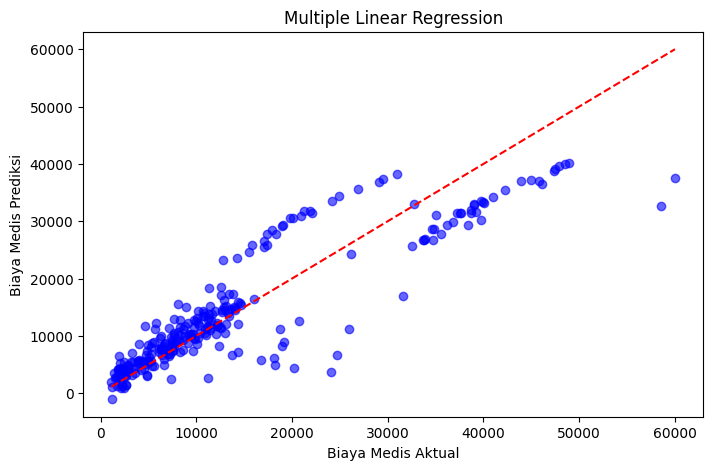

In [11]:
#visualisasi hasil prediksi
plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred_linear,
    color='blue',
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel('Biaya Medis Aktual')
plt.ylabel('Biaya Medis Prediksi')
plt.title('Multiple Linear Regression')
plt.show()

##**7. Membuat model SVR**

In [12]:
model_svr = SVR(kernel='rbf')

#melatih model SVR
model_svr.fit(
    X_train_scaled,
    y_train_scaled
)

y_pred_svr_scaled = model_svr.predict(X_test_scaled)


y_pred_svr = scaler_y.inverse_transform(
    y_pred_svr_scaled.reshape(-1, 1)
).ravel()

hasil_svr = pd.DataFrame({
    'Biaya Aktual': y_test.to_numpy(),
    'Biaya Prediksi': y_pred_svr
})

hasil_svr.head()

,Biaya Aktual,Biaya Prediksi
0,1826.84300,2895.152021
1,20177.67113,5272.192474
2,7421.19455,8606.780854
3,1877.92940,3021.365338
4,15518.18025,18849.091726


Hasil Evaluasi SVR
R-squared: 0.8805402131416991
MSE: 18732259.90200902
MAE: 2505.04840778538


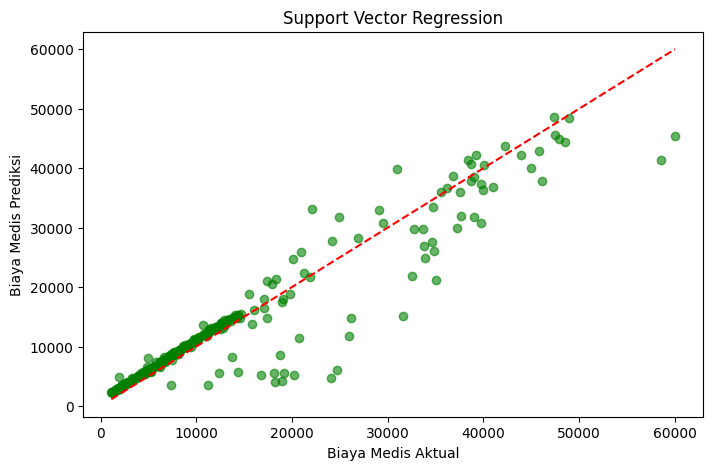

In [13]:
#evaluasi SVR
r2_svr = r2_score(y_test, y_pred_svr)
mse_svr = mean_squared_error(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print('Hasil Evaluasi SVR')
print('R-squared:', r2_svr)
print('MSE:', mse_svr)
print('MAE:', mae_svr)

plt.figure(figsize=(8, 5))

plt.scatter(
    y_test,
    y_pred_svr,
    color='green',
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red',
    linestyle='--'
)

plt.xlabel('Biaya Medis Aktual')
plt.ylabel('Biaya Medis Prediksi')
plt.title('Support Vector Regression')
plt.show()

##**Eksperimen Hyperparameter Tuning**

In [14]:
from sklearn.model_selection import GridSearchCV

parameter = {
    'kernel': ['rbf', 'linear'],
    'C': [1, 10, 100],
    'epsilon': [0.1, 0.2, 0.5]
}

#tuning
grid_search = GridSearchCV(
    estimator=SVR(),
    param_grid=parameter,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(
    X_train_scaled,
    y_train_scaled
)

print('Parameter terbaik:')
print(grid_search.best_params_)

print('\nR-squared validasi terbaik:')
print(grid_search.best_score_)


Parameter terbaik:
{'C': 1, 'epsilon': 0.1, 'kernel': 'rbf'}

R-squared validasi terbaik:
0.8264428335927987


In [15]:
y_pred_tuning_scaled = grid_search.predict(X_test_scaled)

y_pred_tuning = scaler_y.inverse_transform(
    y_pred_tuning_scaled.reshape(-1, 1)
).ravel()

r2_tuning = r2_score(y_test, y_pred_tuning)
mse_tuning = mean_squared_error(y_test, y_pred_tuning)
mae_tuning = mean_absolute_error(y_test, y_pred_tuning)

print('Hasil Evaluasi SVR Setelah Tuning')
print('R-squared:', r2_tuning)
print('MSE:', mse_tuning)
print('MAE:', mae_tuning)

hasil_akhir = pd.DataFrame({
    'Model': [
        'Multiple Linear Regression',
        'SVR Sebelum Tuning',
        'SVR Setelah Tuning'
    ],
    'R-squared': [
        r2_linear,
        r2_svr,
        r2_tuning
    ],
    'MSE': [
        mse_linear,
        mse_svr,
        mse_tuning
    ],
    'MAE': [
        mae_linear,
        mae_svr,
        mae_tuning
    ]
})

hasil_akhir.round(4)

Hasil Evaluasi SVR Setelah Tuning
R-squared: 0.8805402131416991
MSE: 18732259.90200902
MAE: 2505.04840778538


,Model,R-squared,MSE,MAE
0,Multiple Linear Regression,0.7942,3.226385e+07,3920.4713
1,SVR Sebelum Tuning,0.8805,1.873226e+07,2505.0484
2,SVR Setelah Tuning,0.8805,1.873226e+07,2505.0484
